## Challenge: Build a GHZ State

### A. Objective

Build a quantum circuit that puts three qubits into what's known as the **GHZ state**.

### B. Background

The Greenberger–Horne–Zeilinger (GHZ) state is a specific type of entangled quantum state involving at least three qubits. You can think of it as an extension of the two-qubit Bell state to more qubits.

The state vector for a three-qubit GHZ state is:

$$
\vert\text{GHZ}\rangle = \frac{\vert000\rangle + \vert111\rangle}{\sqrt{2}}
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0
\end{bmatrix}
$$

This tells us the three qubits have an equal probability of all being measured as $0$ or all being measured as $1$. All three will always share the same outcome — there is never a mixed measurement result (e.g. $\vert010\rangle$ or $\vert101\rangle$ are impossible).

### C. Task

Design a circuit that prepares this exact state starting from $\vert000\rangle$.

### D. Getting Started

*   A template is included in the exercise files as a starting point.
*   There are multiple valid circuit constructions that achieve the desired GHZ state — any correct approach is acceptable.

In [36]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

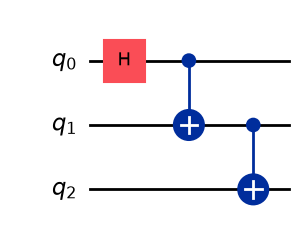

In [37]:
circuit = QuantumCircuit(3)

circuit.h(0)
circuit.cx(0, 1)  #(Control, Target)
circuit.cx(1, 2)  #(Control, Target)

circuit.draw(output='mpl')

In [38]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

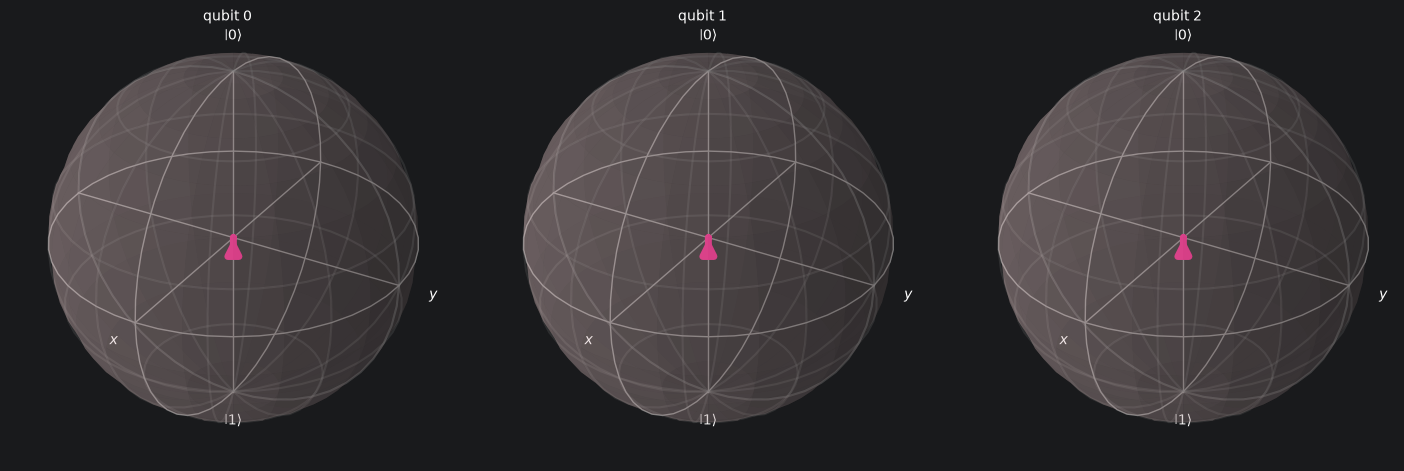

In [39]:
plot_bloch_multivector(statevector)

In [40]:
circuit.measure_all()
simulator = Aer.get_backend('qasm_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=1024).result()

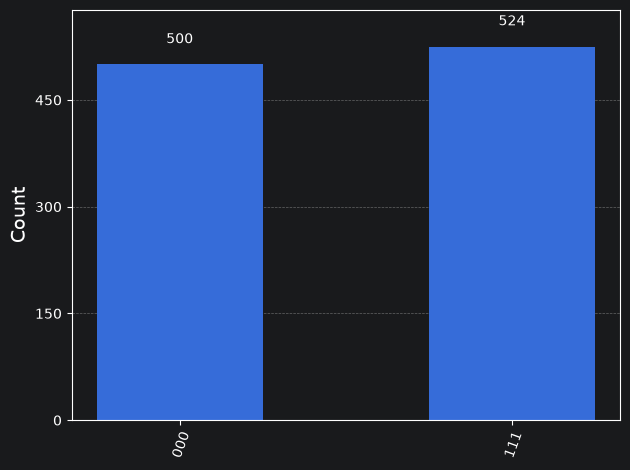

In [41]:
plot_histogram(result.get_counts())

Creating an entangled dependency between all three of qubits shows the statevector having equal non-zero probability amplitudes in its first and last elements, and that corresponds to the simulated results in the histogram which show roughly equal outcomes of 000 and 111

## Bonus Challenges

### E. Extend to Four Qubits

Extend your three-qubit $\vert\text{GHZ}\rangle$ circuit to entangle **four** qubits instead of three.

### F. Build the W State

Build a quantum circuit that puts three qubits into the $\vert W\rangle$ state:

$$
\vert W\rangle = \frac{\vert001\rangle + \vert010\rangle + \vert100\rangle}{\sqrt{3}}
$$

Unlike the GHZ state, the $\vert W\rangle$ state has probability amplitude spread across three *different* basis states, each with exactly one qubit measured as $1$.

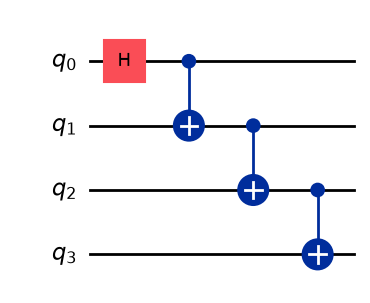

In [42]:
circuit4 = QuantumCircuit(4)

circuit4.h(0)
circuit4.cx(0, 1)
circuit4.cx(1, 2)
circuit4.cx(2, 3)  # extra CNOT chains the fourth qubit to the entangled group

circuit4.draw(output='mpl')

In [43]:
simulator = Aer.get_backend('statevector_simulator')
compiled4 = transpile(circuit4, simulator)
result4 = simulator.run(compiled4).result()
statevector4 = result4.get_statevector()
array_to_latex(statevector4)

<IPython.core.display.Latex object>

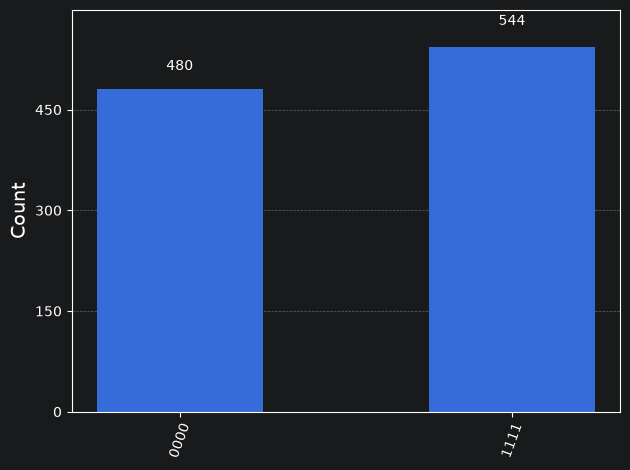

In [44]:
circuit4.measure_all()
qasm_sim = Aer.get_backend('qasm_simulator')
compiled4_meas = transpile(circuit4, qasm_sim)
result4_meas = qasm_sim.run(compiled4_meas, shots=1024).result()
plot_histogram(result4_meas.get_counts())

Extending the pattern from the 3-qubit GHZ circuit, each additional qubit just needs one more CNOT chained off the previous qubit. The statevector again shows only two non-zero amplitudes — this time on $\vert0000\rangle$ and $\vert1111\rangle$ — and the histogram confirms roughly equal measurement outcomes of `0000` and `1111`, with no mixed results.

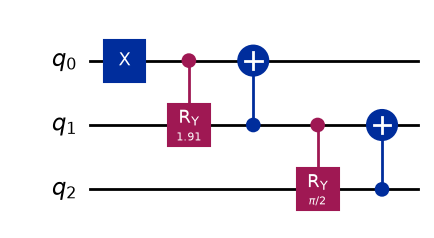

In [45]:
from math import sqrt, acos

circuit_w = QuantumCircuit(3)

circuit_w.x(0)  # start the single excitation on q0
circuit_w.cry(2 * acos(sqrt(1 / 3)), 0, 1)  # split off 2/3 of the amplitude onto q1
circuit_w.cx(1, 0)  # move the "holder" role to q1 where it split
circuit_w.cry(2 * acos(sqrt(1 / 2)), 1, 2)  # split q1's remaining share evenly with q2
circuit_w.cx(2, 1)  # move the "holder" role to q2 where it split

circuit_w.draw(output='mpl')

In [46]:
compiled_w = transpile(circuit_w, simulator)
result_w = simulator.run(compiled_w).result()
statevector_w = result_w.get_statevector()
array_to_latex(statevector_w)

<IPython.core.display.Latex object>

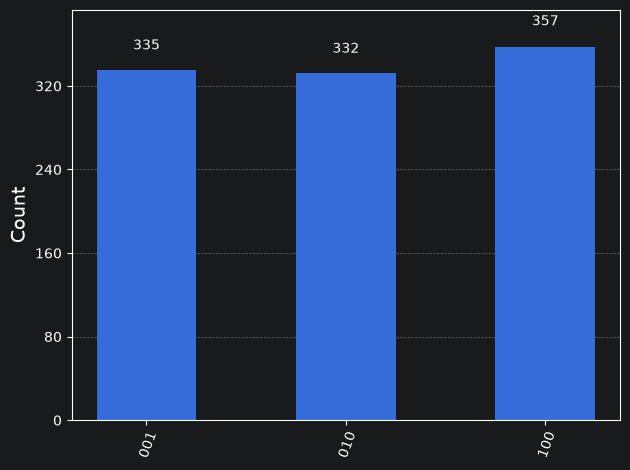

In [47]:
circuit_w.measure_all()
compiled_w_meas = transpile(circuit_w, qasm_sim)
result_w_meas = qasm_sim.run(compiled_w_meas, shots=1024).result()
plot_histogram(result_w_meas.get_counts())

Unlike the GHZ circuit, this one uses controlled rotations ($R_Y$) instead of Hadamards, since the excitation needs to be divided unevenly at each step (first $1/3$ vs. $2/3$, then split the remainder $1/2$ vs. $1/2$) rather than split 50/50 from the start. The resulting statevector has three equal, non-zero amplitudes on $\vert001\rangle$, $\vert010\rangle$, and $\vert100\rangle$ — matching $\vert W\rangle$ — and the histogram shows roughly equal counts split across those three outcomes only.